# Degree Heating Weeks

```{glue:figure} dhw_all
:scale: 60%
:align: center
```

**Figure. NOAA Coral Reef Watch Degree Heating Weeks at the virtual station in the vicinity of Palau.** The Degree Heating Week (DHW) value is shown on the vertical axis on the right. The coral bleaching heat stress level (or Bleaching Alert Level) – Warning, Alert Level 1, Alert Level 2 – are color-coded and shaded-in along the bottom horizontal axis.  Red dashed lines across the graphs indicate DHW threshold values of 4- and 8-degree Celsius-weeks (triggers for Bleaching Alert Levels 1 and 2, respectively). The representative SST value is shown on the vertical axis on the left.  The monthly mean climatology, the MMM, and the bleaching threshold SST are also provided on the graph. 

In [1]:
# CIndRA notebook display standard
import matplotlib as mpl

mpl.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'figure.dpi': 100,
    'savefig.dpi': 300,
})

In [2]:
import warnings
warnings.filterwarnings("ignore")

import sys
import os
import os.path as op
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from myst_nb import glue

# Locate CIndRA independently of the directory used to launch Jupyter.
search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next((p for p in search_roots if (p / 'functions' / 'ocean.py').is_file()), None)
if repo_root is None:
    raise FileNotFoundError('Could not locate the CIndRA repository root.')

# ind_setup is provided by the companion indicators_setup directory.
setup_candidates = [repo_root / 'indicators_setup']
setup_candidates.extend(parent / 'indicators_setup' for parent in repo_root.parents)
indicators_setup_dir = next(
    (p for p in setup_candidates if (p / 'ind_setup').is_dir()),
    None,
)
if indicators_setup_dir is None:
    raise FileNotFoundError(
        'Could not locate indicators_setup/ind_setup. Place indicators_setup '
        'in CIndRA or one of its parent directories.'
    )

sys.path.insert(0, str(indicators_setup_dir))
from ind_setup.plotting import plot_dhw, plot_dhw_perpetual_year, plot_dhw_bleaching_levels, add_oni_cat

sys.path.insert(0, str(repo_root / 'functions'))
from ocean import process_bleaching_levels
from data_downloaders import download_oni_index

## Setup

Define area of interest

In [3]:
path_data = repo_root / 'data' / 'sea_surface_temperature' / 'sst_daily_1981_2024_palau.nc'
path_figs = repo_root / 'matrix_cc' / 'figures'
path_figs.mkdir(parents=True, exist_ok=True)

lon_site, lat_site = 134.368203, 7.322074

# Area of interest
lon_range = [129.4088, 137.0541]
lat_range = [1.5214, 11.6587]

EEZ shapefile

In [4]:
shp_f = repo_root / 'data' / 'Palau_EEZ' / 'pw_eez_pol_april2022.shp'
if not shp_f.is_file():
    raise FileNotFoundError(f'Palau EEZ shapefile not found: {shp_f}')
shp_eez = gpd.read_file(shp_f)

### Download Data

The NOAA Coral Reef Watch (CRW) daily global 5km satellite coral bleaching Degree Heating Week (DHW) product for the virtual station in the vicinity of Palau shows accumulated heat stress, which can lead to coral bleaching and death (Figure 15). Bleaching heat stress is categorized into risk levels based on the DHW values, which are directly related to the timing and intensity of coral bleaching – Bleaching Warning (0 < DHW < 4), Bleaching Alert Level 1 (4 <= DHW < 8), and (8 <= DHW < 12).  At Bleaching Alert Level 1, significant bleaching is expected within a few weeks of the alert. At Bleaching Alert Level 2 and above, severe, widespread bleaching and significant coral mortality are likely.  

https://coralreefwatch.noaa.gov/product/5km/methodology.php#dhw

In [5]:
"""
Name:
Palau
Polygon Middle Longitude:
134.4250 
Polygon Middle Latitude:
7.6750  
Averaged Maximum Monthly Mean:
29.2309
Averaged Monthly Mean (Jan-Dec):
28.0424 27.7264 27.8581 28.4679 29.1780 29.2309 28.8550 28.7810 28.8377 29.0823 29.1088 28.8078
First Valid DHW Date:
1985 25 03
First Valid BAA Date:
1985 31 03
"""
data_crw = pd.read_csv(
    "https://coralreefwatch.noaa.gov/product/vs/data/palau.txt", sep=r"\s+", skiprows=20
)
data_crw.to_csv(repo_root / 'data' / 'data_crw_palau.csv')
data_crw.index = pd.to_datetime(
    data_crw["YYYY"].astype(str)
    + data_crw["MM"].astype(str)
    + data_crw["DD"].astype(str),
    format="%Y%m%d",
)
data_crw = data_crw.groupby(level=0).max()
# data_crw = data_crw[~data_crw.index.duplicated()]
data_crw.sort_index(inplace=True)
# data_crw = data_crw.resample('W').mean()
data_crw = data_crw[:"2024"]


## Analysis


Stress Level <br>

No Stress HotSpot <= 0 <br>
Bleaching Watch 0 < HotSpot < 1 <br>
Bleaching Warning 1 <= HotSpot and 0 < DHW < 4 <br>
Bleaching Alert Level 1 1 <= HotSpot and 4 <= DHW < 8 <br>
Bleaching Alert Level 2	1 <= HotSpot and 8 <= DHW <br>

### Full time period

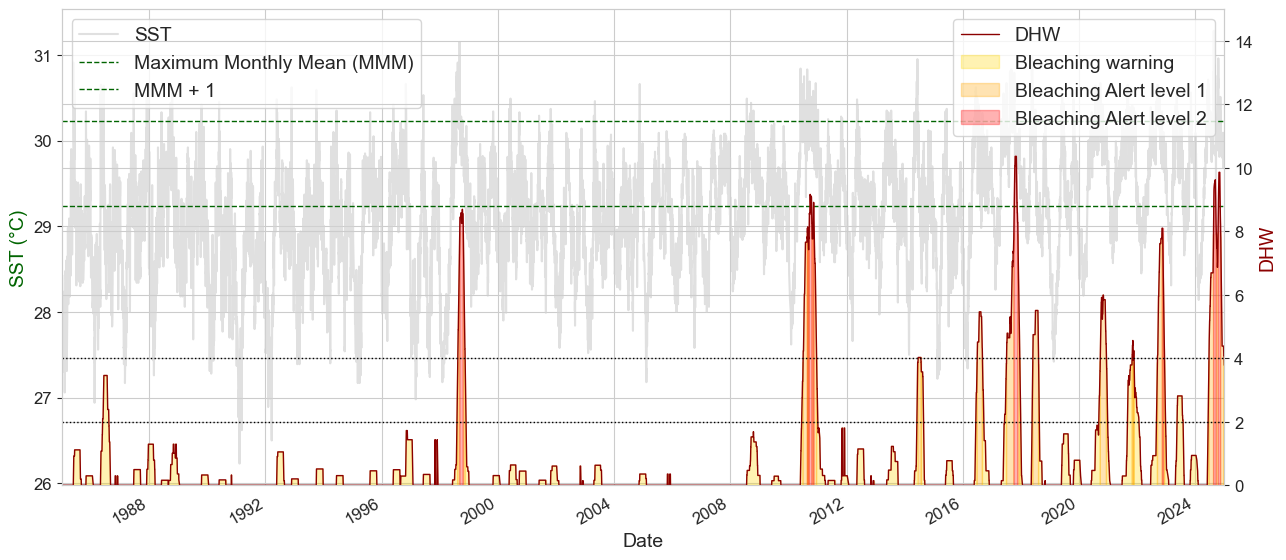

In [6]:
fig, ax2 = plot_dhw(data_crw)
plt.savefig(op.join(path_figs, "F13_DHW.png"), dpi=300, bbox_inches="tight")
glue("dhw_all", fig, display=False)

#### Last 10 years

(np.float64(16071.0), np.float64(19723.0))

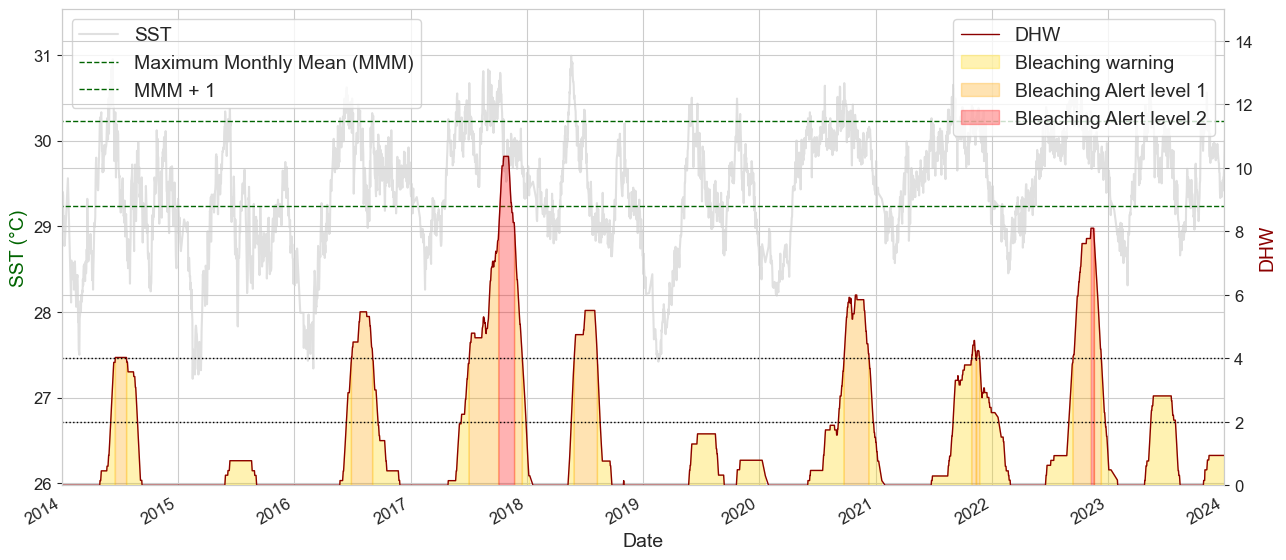

In [7]:
fig, ax2 = plot_dhw(data_crw)
ax2.set_xlim("2014", "2024")

#### Bleaching alert levels: change

In [8]:
df, days_pivot = process_bleaching_levels(data_crw)

In [9]:
days_pivot/10

period,First 10 years,Last 10 years
bleaching_level,,
No stress,143.8,26.0
Bleaching Watch,187.9,199.8
Bleaching Warning,15.5,79.0
Alert level 1,0.0,34.9
Alert level 2,0.0,7.6


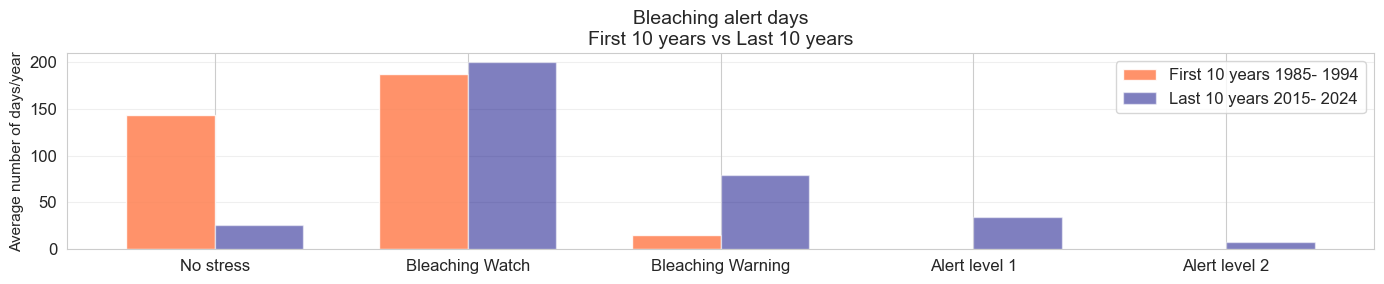

In [10]:
fig, _ = plot_dhw_bleaching_levels(df, days_pivot)
plt.savefig(op.join(path_figs, "F13_DHW_days_year_level.png"), dpi=300, bbox_inches="tight")


#### Perpetual Year

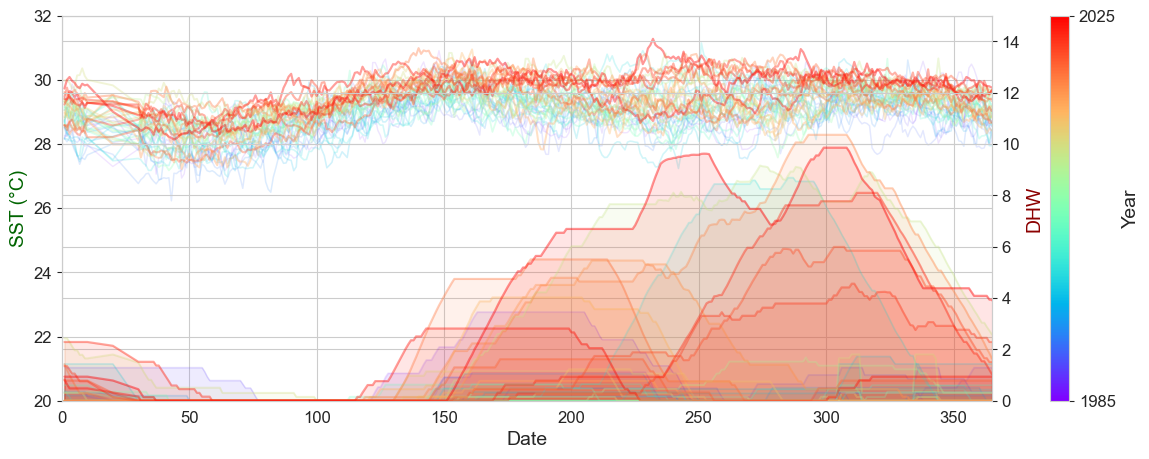

In [11]:
fig, ax2 = plot_dhw_perpetual_year(data_crw, yeari=1985, yeare=2025)

### ONI index analysis

In [12]:
p_data = 'https://psl.noaa.gov/data/correlation/oni.data'
df1 = download_oni_index(p_data)
df1['dhw'] = df.select_dtypes(include="number").resample("MS").mean()['DHW_from_90th_HS>1']
df1 = df1.dropna()
df1 = add_oni_cat(df1, lims = [-0.5, 0.5])

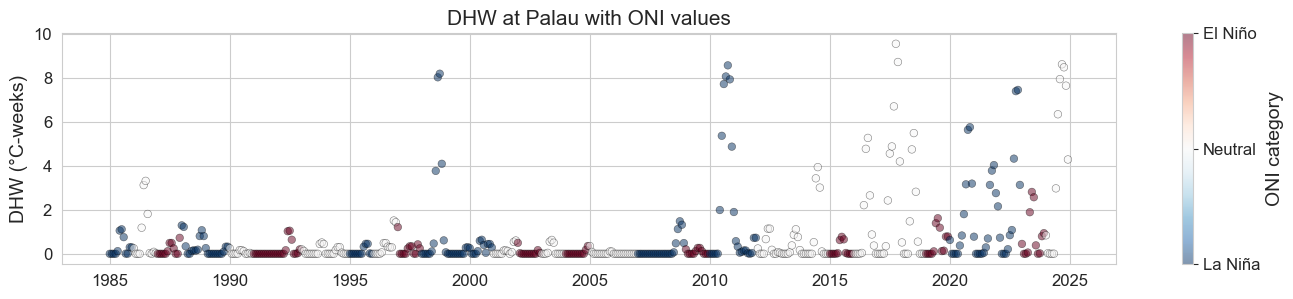

In [13]:
fig, ax = plt.subplots(figsize=(17, 3))
# im = ax.scatter(df1.index, df1['dhw'], c=df1.ONI, s = 20, cmap = 'RdBu_r', vmin = -1, vmax = 1)
im = ax.scatter(df1.index, df1['dhw'], c=df1.oni_cat, s = 30, cmap = 'RdBu_r', ec = 'k', linewidths = .4, vmin = -1, vmax = 1, alpha = .5)
cbar = plt.colorbar(im, ax=ax, label='ONI category')
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["La Niña", "Neutral", "El Niño"])
ax.set_ylabel('DHW (°C-weeks)')
ax.set_title('DHW at Palau with ONI values')
plt.savefig(op.join(path_figs, "F13_DHW_oni_cat.png"), dpi=300, bbox_inches="tight")



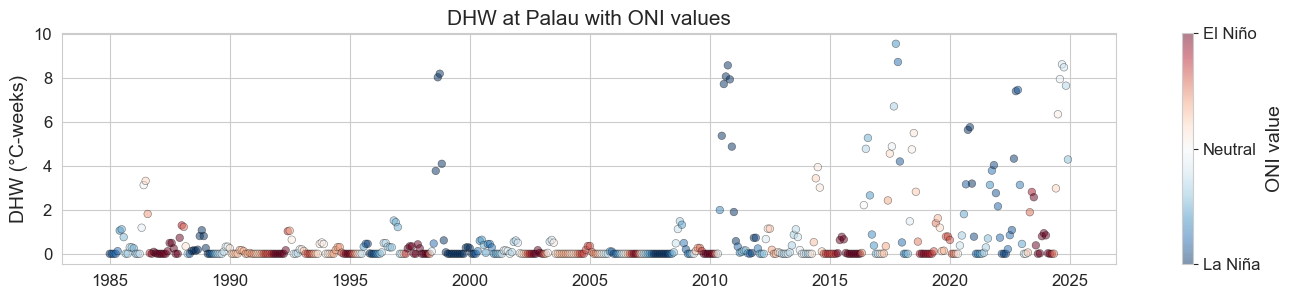

In [14]:
fig, ax = plt.subplots(figsize=(17, 3))
# im = ax.scatter(df1.index, df1['dhw'], c=df1.ONI, s = 20, cmap = 'RdBu_r', vmin = -1, vmax = 1)
im = ax.scatter(df1.index, df1['dhw'], c=df1.ONI, s = 30, cmap = 'RdBu_r', ec = 'k', linewidths = .4, vmin = -1, vmax = 1, alpha = .5)
cbar = plt.colorbar(im, ax=ax, label='ONI value')
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["La Niña", "Neutral", "El Niño"])
ax.set_ylabel('DHW (°C-weeks)')
ax.set_title('DHW at Palau with ONI values')
plt.savefig(op.join(path_figs, "F13_DHW_oni_cat.png"), dpi=300, bbox_inches="tight")



## Interpretation and reproducibility notes

- Results apply to the configured station, site or EEZ and should not be generalized without checking spatial representativeness.
- Gridded SST resolution, data gaps and the selected climatological baseline affect anomalies, extremes and marine-heatwave metrics.
- Linear trends are descriptive unless the notebook explicitly accounts for temporal autocorrelation and other statistical assumptions.
- Confirm the printed source, analysis period, reference period and output paths before using figures or tables in reporting.